In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [10]:
path = "data/merged.csv"
merged = pd.read_csv(path, parse_dates=["date"])

In [11]:
merged.head()

,date,price,Conventional Oil,Non-Conventional Oil,prod_change_conventional,price_change,price_lag_6,price_lag_12,prod_change
0,2007-01-01,60.85,2707743.4,5604533.2,NaN,NaN,NaN,NaN,NaN
1,2007-02-01,57.35,2450594.2,5414892.8,-257149.2,-3.50,NaN,NaN,-189640.4
2,2007-03-01,61.97,2703836.8,6082110.5,253242.6,4.62,NaN,NaN,667217.7
3,2007-05-01,64.43,2614545.2,5460600.2,-89291.6,2.46,NaN,NaN,-621510.3
4,2007-06-01,65.09,2493203.4,5116667.3,-121341.8,0.66,NaN,NaN,-343932.9


In [12]:
merged.tail()

,date,price,Conventional Oil,Non-Conventional Oil,prod_change_conventional,price_change,price_lag_6,price_lag_12,prod_change
159,2025-08-01,68.39,3183810.5,17662799.8,18743.9,1.75,70.41,74.36,-434845.5
160,2025-09-01,64.36,3062725.8,17030025.6,-121084.7,-4.03,69.81,80.90,-632774.2
161,2025-10-01,62.59,3211750.9,17172423.0,149025.1,-1.77,72.44,84.54,142397.4
162,2025-12-01,59.47,3246489.3,18460827.5,34738.4,-3.12,71.61,80.70,1288404.5
163,2026-01-01,57.26,3240700.9,17518453.6,-5788.4,-2.21,60.59,84.70,-942373.9


## Linear Regression

In [20]:
x = merged[["price"]]
y = merged["Non-Conventional Oil"]

In [21]:
x.head()

,price
0,60.85
1,57.35
2,61.97
3,64.43
4,65.09


In [22]:
y.head()

0    5604533.2
1    5414892.8
2    6082110.5
3    5460600.2
4    5116667.3
Name: Non-Conventional Oil, dtype: float64

In [23]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [25]:
model = LinearRegression()

model.fit(x_train, y_train)

LinearRegression()

In [26]:
predictions = model.predict(x_test)

In [27]:
print("slope: ", model.coef_[0])

slope:  -58438.95966340903


In [28]:
print("intercept:", model.intercept_)

intercept: 15828513.296662169


In [29]:
print("R^2 score:", model.score(x_test, y_test)) 

R^2 score: -0.03628758782814101


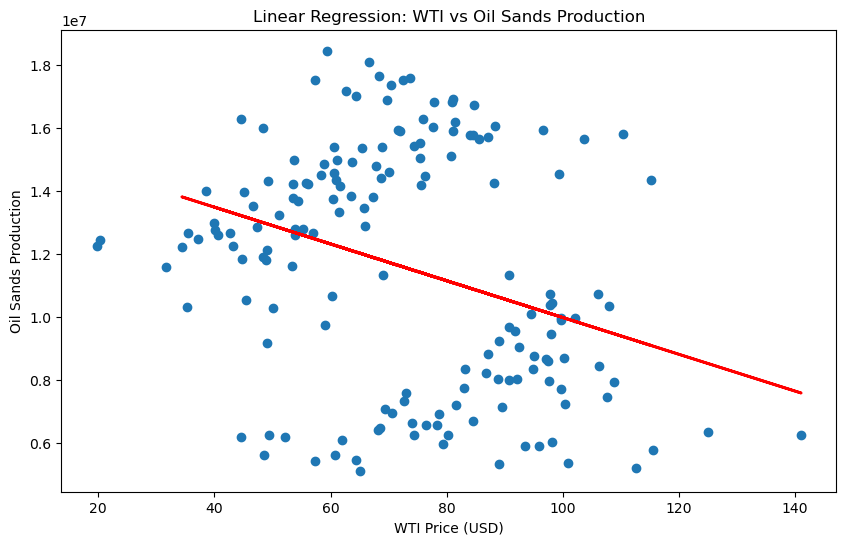

In [33]:
plt.figure(figsize=(10,6))
plt.scatter(x, y)
plt.plot (x_test, predictions, color="red", linewidth=2)
plt.xlabel("WTI Price (USD)")
plt.ylabel("Oil Sands Production")
plt.title("Linear Regression: WTI vs Oil Sands Production")

plt.show()